In [19]:
import numpy as np

rng = np.random.default_rng(seed=42)
arr = rng.integers(0, 100, size=(5, 6))
print("Массив:\n", arr)

Массив:
 [[ 8 77 65 43 43 85]
 [ 8 69 20  9 52 97]
 [73 76 71 78 51 12]
 [83 45 50 37 18 92]
 [78 64 40 82 54 44]]


In [20]:
print("Форма:", arr.shape)
print("Тип данных:", arr.dtype)
print("Размер:", arr.size)
print("Число осей:", arr.ndim)

Форма: (5, 6)
Тип данных: int64
Размер: 30
Число осей: 2


In [21]:
print("Сумма всех элементов:", arr.sum())
print("Сумма по строкам:", arr.sum(axis=1))
print("Сумма по столбцам:", arr.sum(axis=0))
print("Среднее:", arr.mean())
print("Стандартное отклонение:", arr.std())
print("Минимум:", arr.min(), "— Максимум:", arr.max())
print("Медиана:", np.median(arr))

Сумма всех элементов: 1624
Сумма по строкам: [321 255 361 325 362]
Сумма по столбцам: [250 331 246 249 218 330]
Среднее: 54.13333333333333
Стандартное отклонение: 26.172165027414568
Минимум: 8 — Максимум: 97
Медиана: 53.0


In [22]:
print("Транспонирование:\n", arr.T)
print("Изменение формы (3×10):\n", arr.reshape(3, 10))
print("Выравнивание:", arr.flatten())

Транспонирование:
 [[ 8  8 73 83 78]
 [77 69 76 45 64]
 [65 20 71 50 40]
 [43  9 78 37 82]
 [43 52 51 18 54]
 [85 97 12 92 44]]
Изменение формы (3×10):
 [[ 8 77 65 43 43 85  8 69 20  9]
 [52 97 73 76 71 78 51 12 83 45]
 [50 37 18 92 78 64 40 82 54 44]]
Выравнивание: [ 8 77 65 43 43 85  8 69 20  9 52 97 73 76 71 78 51 12 83 45 50 37 18 92
 78 64 40 82 54 44]


In [23]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print("Поэлементное произведение:\n", a * b)
print("Матричное произведение:\n", a @ b)
print("Определитель a:", np.linalg.det(a))
print("Обратная матрица a:\n", np.linalg.inv(a))
eigenvalues, eigenvectors = np.linalg.eig(a)
print("Собственные значения:", eigenvalues)
print("Собственные векторы:\n", eigenvectors)

Поэлементное произведение:
 [[ 5 12]
 [21 32]]
Матричное произведение:
 [[19 22]
 [43 50]]
Определитель a: -2.0000000000000004
Обратная матрица a:
 [[-2.   1. ]
 [ 1.5 -0.5]]
Собственные значения: [-0.37228132  5.37228132]
Собственные векторы:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [24]:
arr_float = arr.astype(np.float64)
arr_normed = (arr_float - arr_float.min()) / (arr_float.max() - arr_float.min())
print("Min-Max нормализация:\n", arr_normed.round(3))

Min-Max нормализация:
 [[0.    0.775 0.64  0.393 0.393 0.865]
 [0.    0.685 0.135 0.011 0.494 1.   ]
 [0.73  0.764 0.708 0.787 0.483 0.045]
 [0.843 0.416 0.472 0.326 0.112 0.944]
 [0.787 0.629 0.36  0.831 0.517 0.404]]


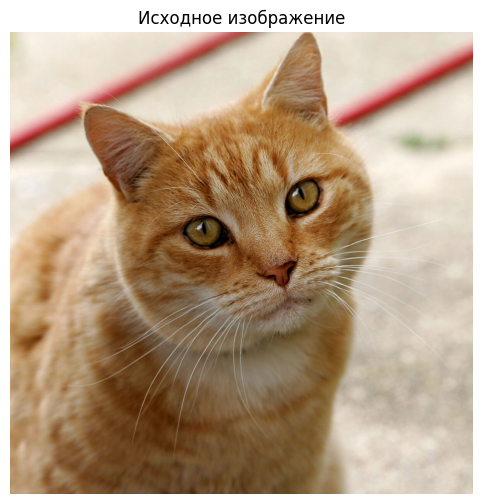

In [25]:
import cv2
import matplotlib.pyplot as plt

img_path = "cat.jpg"

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()


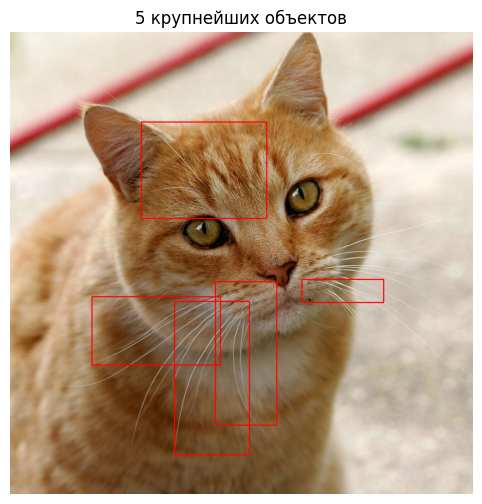

In [26]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

img_result = img_rgb.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_result, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(8, 6))
plt.imshow(img_result)
plt.title("5 крупнейших объектов")
plt.axis("off")
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt


def draw_rectangle(image: np.ndarray, pt1: tuple, pt2: tuple, color: tuple, thickness: int = 2) -> np.ndarray:
    img = image.copy()
    x1, y1 = min(pt1[0], pt2[0]), min(pt1[1], pt2[1])
    x2, y2 = max(pt1[0], pt2[0]), max(pt1[1], pt2[1])
    h, w = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w - 1, x2), min(h - 1, y2)
    t = max(1, thickness)
    half = t // 2

    y_top_start = max(0, y1 - half)
    y_top_end = min(h, y1 - half + t)
    img[y_top_start:y_top_end, x1:x2 + 1] = color

    y_bot_start = max(0, y2 - half)
    y_bot_end = min(h, y2 - half + t)
    img[y_bot_start:y_bot_end, x1:x2 + 1] = color

    x_left_start = max(0, x1 - half)
    x_left_end = min(w, x1 - half + t)
    img[y1:y2 + 1, x_left_start:x_left_end] = color

    x_right_start = max(0, x2 - half)
    x_right_end = min(w, x2 - half + t)
    img[y1:y2 + 1, x_right_start:x_right_end] = color

    return img

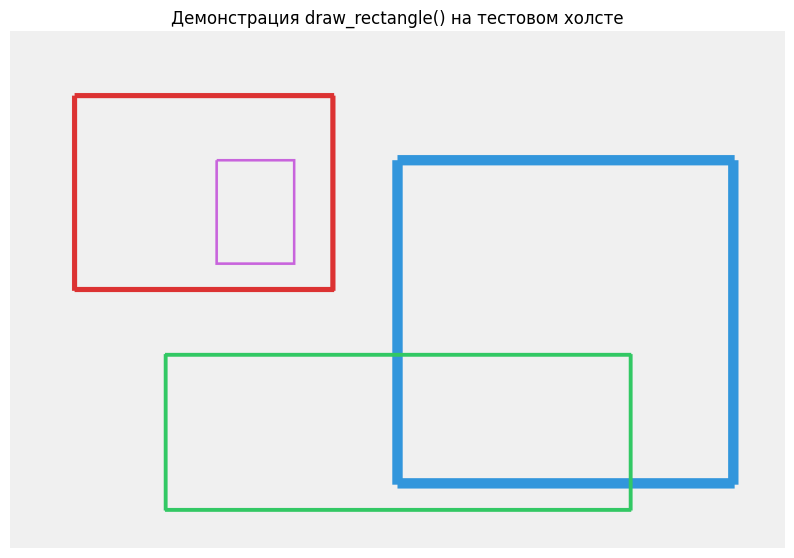

In [28]:
canvas = np.ones((400, 600, 3), dtype=np.uint8) * 240

canvas = draw_rectangle(canvas, (50, 50), (250, 200), color=(220, 50, 50), thickness=4)
canvas = draw_rectangle(canvas, (300, 100), (560, 350), color=(50, 150, 220), thickness=8)
canvas = draw_rectangle(canvas, (120, 250), (480, 370), color=(50, 200, 100), thickness=3)
canvas = draw_rectangle(canvas, (160, 100), (220, 180), color=(200, 100, 220), thickness=2)

plt.figure(figsize=(10, 7))
plt.imshow(canvas)
plt.title("Демонстрация draw_rectangle() на тестовом холсте")
plt.axis("off")
plt.show()

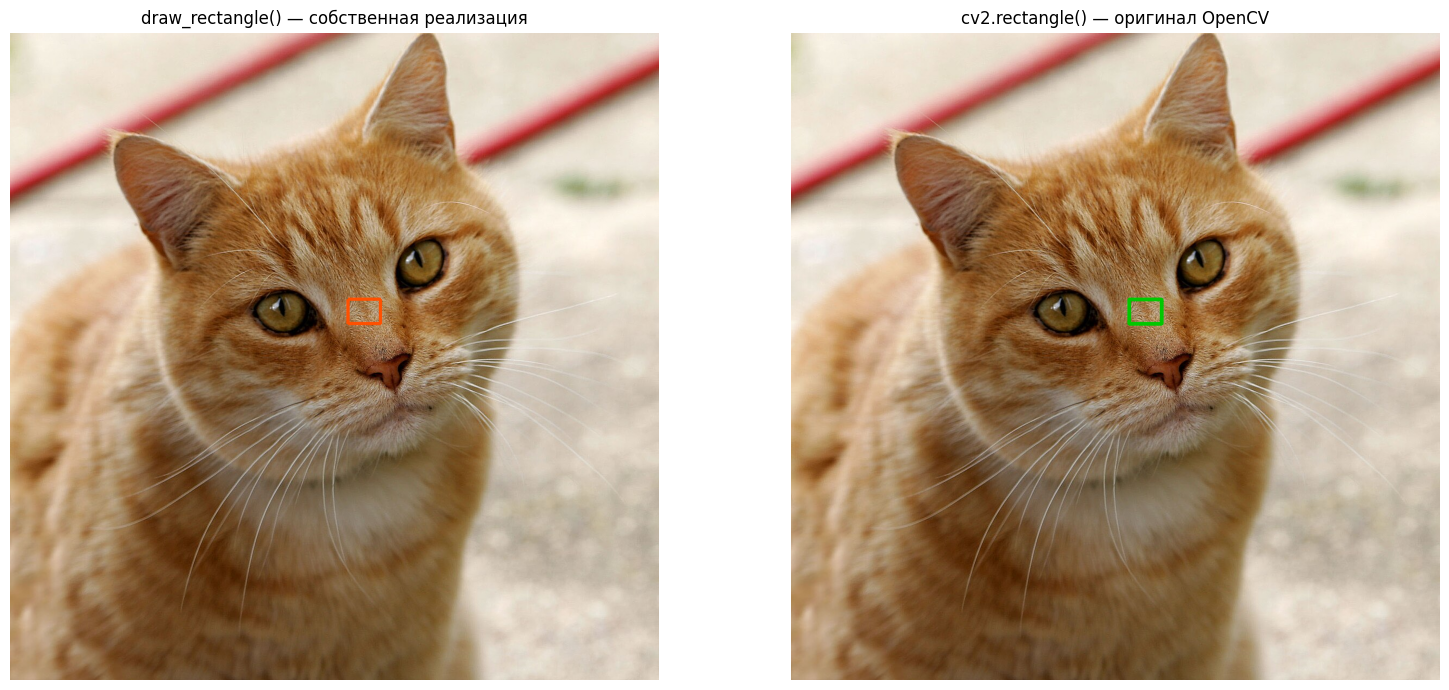

In [29]:
import cv2

img_bgr2 = cv2.imread(img_path)
img_rgb2 = cv2.cvtColor(img_bgr2, cv2.COLOR_BGR2RGB)

largest = contours_sorted[0]
x, y, w, h = cv2.boundingRect(largest)

img_custom_rect = draw_rectangle(img_rgb2, (x, y), (x + w, y + h), color=(255, 80, 0), thickness=6)

img_cv_rect = img_rgb2.copy()
cv2.rectangle(img_cv_rect, (x, y), (x + w, y + h), (0, 200, 0), 6)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img_custom_rect)
axes[0].set_title("draw_rectangle() — собственная реализация")
axes[0].axis("off")
axes[1].imshow(img_cv_rect)
axes[1].set_title("cv2.rectangle() — оригинал OpenCV")
axes[1].axis("off")
plt.tight_layout()
plt.show()